In [1]:
import cv2 as cv
import os
import numpy as np
from matplotlib import pyplot as plt
from typing import List
import imutils
# import pytesseract as tes
from easyocr import Reader
import torch
from langchain_core.prompts import PromptTemplate
from langchain_ollama import OllamaLLM


In [4]:
def show_images_plt(images: cv.typing.MatLike | List[cv.typing.MatLike]) -> None:
    """plot image or list of images using plt of matplotlib"""

    if isinstance(images, cv.typing.MatLike): 
        plt.imshow(images, cmap='grey')
        plt.axis('off')
        plt.show()

    if isinstance(images, list):
        for img in images:
            if not isinstance(img, cv.typing.MatLike): 
                continue

            plt.imshow(img, cmap='grey')
            plt.show()




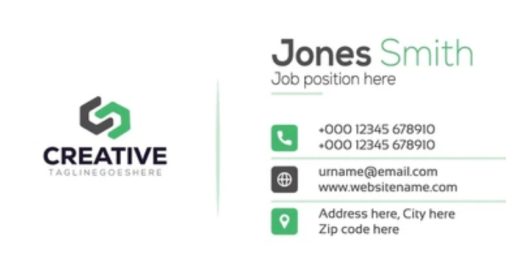

In [13]:
with open('../card tests/Screenshot 2025-09-15 175837.png', 'rb') as f:
    content = f.read()

np_array = np.frombuffer(content, dtype= 'uint8')
img_np = cv.imdecode(np_array, cv.IMREAD_COLOR_BGR)

show_images_plt(img_np)

In [6]:
test_images = os.listdir('../card tests')
test_images = [f'../card tests/{file}' for file in test_images]

In [7]:
test_images

['../card tests/0001-01-gra-300x225.jpeg',
 '../card tests/Screenshot 2025-09-15 175837.png',
 '../card tests/Screenshot 2025-09-15 175856.png',
 '../card tests/Screenshot 2025-09-15 175913.png',
 '../card tests/Screenshot 2025-09-15 175919.png',
 '../card tests/Screenshot 2025-09-16 145306.png',
 '../card tests/Screenshot 2025-09-20 182045.png']

## Pre Processing

In [8]:
def show_image_imshow(img: str, win_name: str = "image") -> None:
    """show the image in rgb format using cv"""
    cv.imshow(win_name, img) #show the image in a window
    k = cv.waitKey(0) #get the key that the user pressed
    if k == ord('q'): #if the user pressed q ord() -> get the unicode of the key pressed
        cv.destroyAllWindows()
    

In [9]:
def show_images_plt(images: cv.typing.MatLike | List[cv.typing.MatLike]) -> None:
    """plot image or list of images using plt of matplotlib"""

    if isinstance(images, cv.typing.MatLike): 
        plt.imshow(images, cmap='grey')
        plt.axis('off')
        plt.show()

    if isinstance(images, list):
        for img in images:
            if not isinstance(img, cv.typing.MatLike): 
                continue

            plt.imshow(img, cmap='grey')
            plt.show()




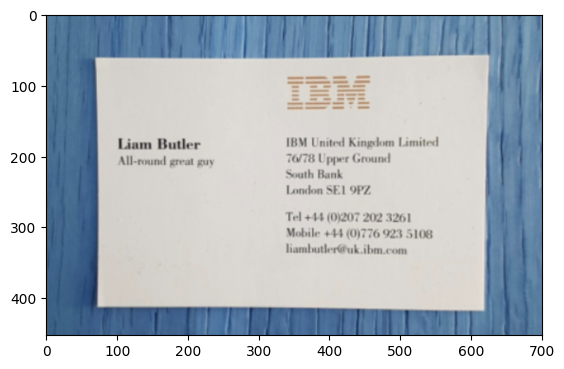

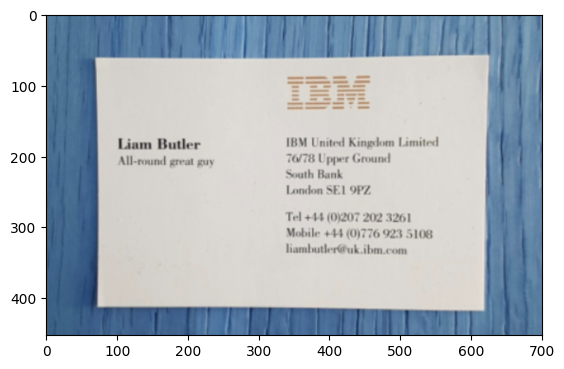

In [10]:
img = [cv.imread(test_images[5]), cv.imread(test_images[5])]

show_images_plt(img)

In [11]:
def convert_to_gray(img):
    """convert an image to gray scale"""
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    return gray

In [12]:
def otsu_threshold(img):
    """binarization using otsu method"""
    threshold_img = cv.threshold(img, 0, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)
    return threshold_img

In [53]:
def gausian_threshold(img):
    """binarization using gausian method"""
    gausian_img = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 9)
    return gausian_img


In [54]:
def adaptive_gausian(img):
    """binarization using adaptive gausian method"""
    adaptive_gausian_img = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 9)
    return adaptive_gausian_img


In [55]:
def gau_blur(img):
    """blur using gausian method"""
    gau_img = cv.GaussianBlur(img, (3,3), 0)
    return gau_img

In [56]:
def med_blur(img):
    med_img = cv.medianBlur(img, 1)
    return med_img

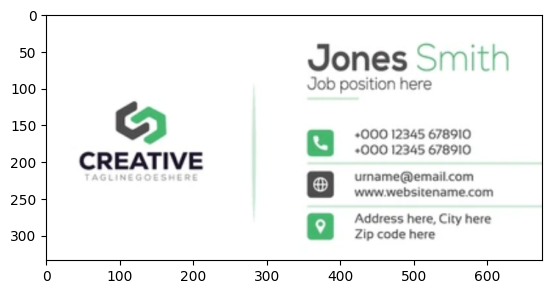

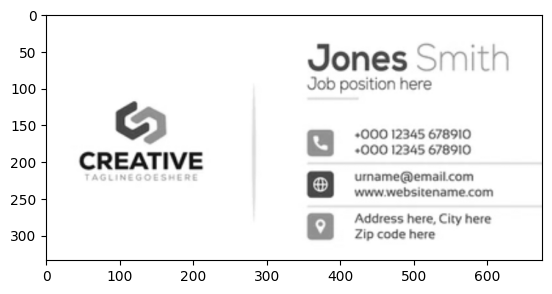

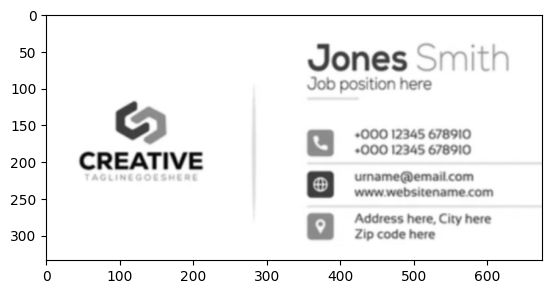

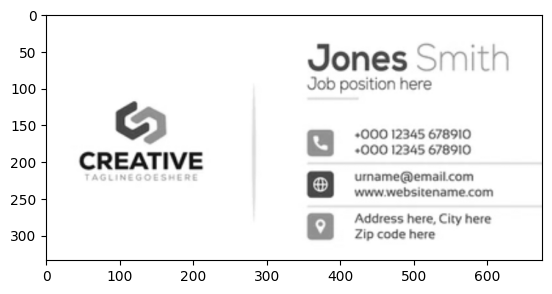

In [57]:
img = cv.imread(test_images[1])
gray = convert_to_gray(img)
gau_blur_img = gau_blur(gray)
med_blur_img = med_blur(gray)

show_images_plt([img, gray, gau_blur_img, med_blur_img])

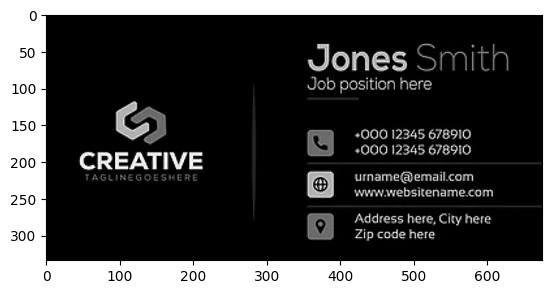

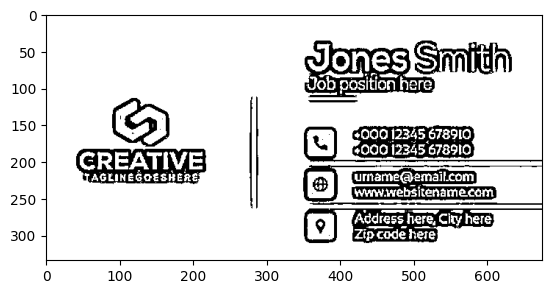

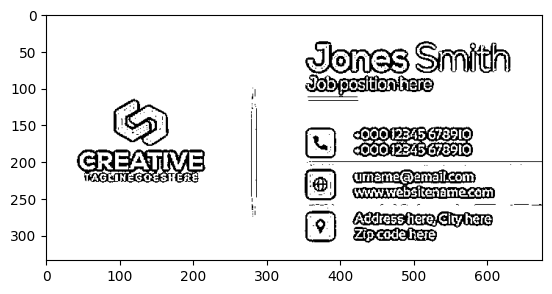

In [58]:
kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
img = cv.imread(test_images[1])
img = cv.bitwise_not(img)
sharp = cv.filter2D(img, -1, kernel)
gray = convert_to_gray(sharp)

gau_img = gausian_threshold(gray)
adap_image = adaptive_gausian(gray)
show_images_plt([gray, gau_img, adap_image])


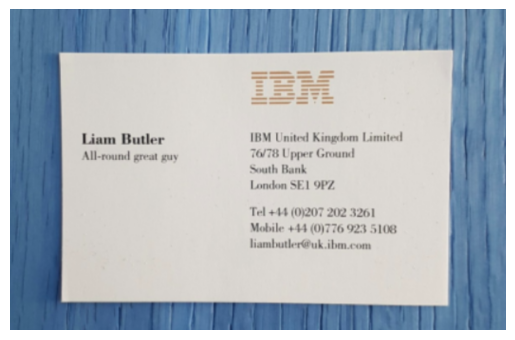

453 701


In [59]:
img = cv.imread(test_images[5])
original = img.copy()
show_images_plt(img)
(H, W) = img.shape[:2]
print(H, W)

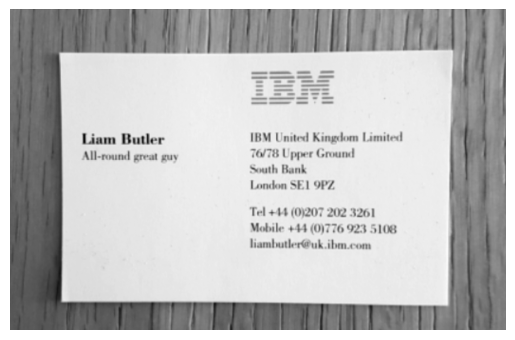

In [60]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
show_images_plt(gray)

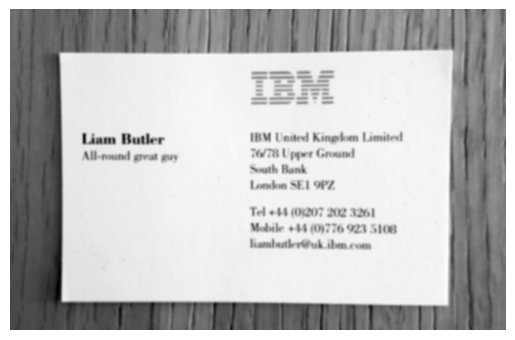

In [61]:
blur = cv.GaussianBlur(gray, (5, 5), 0)
show_images_plt(blur)


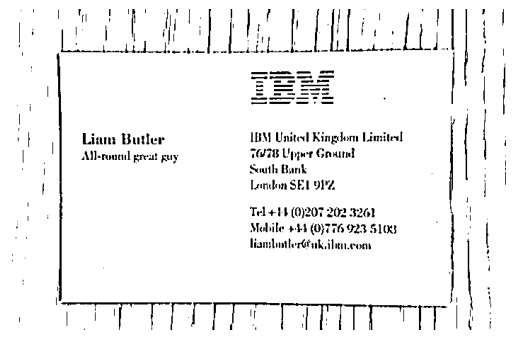

In [62]:
adap_image = adaptive_gausian(gray)
show_images_plt(adap_image)

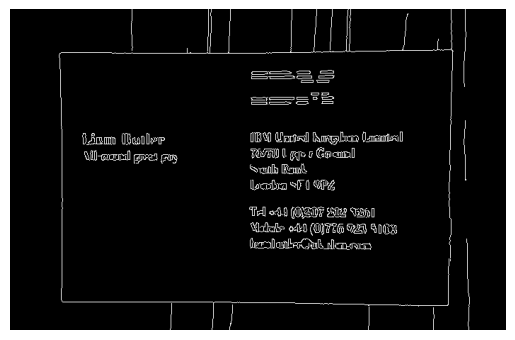

In [63]:
edged = cv.Canny(blur, 60, 160)
show_images_plt(edged)

In [64]:
def find_contours(img): # EXTERNAL
  conts = cv.findContours(img, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
  conts = imutils.grab_contours(conts)
  conts = sorted(conts, key = cv.contourArea, reverse = True)[:]
  return conts

In [65]:
conts = find_contours(edged.copy())

In [66]:
for c in conts:
  perimeter = cv.arcLength(c, True)
  approximation = cv.approxPolyDP(c, 0.02 * perimeter, True)
  if len(approximation) == 4:
    larger = approximation
    break

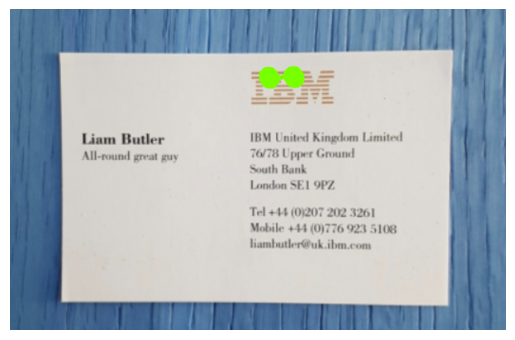

In [67]:
cv.drawContours(img, larger, -1, (120,255,0), 28)
cv.drawContours(img, [larger], -1, (120,255,0), 2)
show_images_plt(img)

In [24]:
#resize image

img = cv.imread(test_images[1])
print(img.shape)
height, width, _ = img.shape
scale = 1.5
img_scaled = cv.resize(img,(int(width*scale), int(height*scale)), cv.INTER_LANCZOS4 )
print(img_scaled.shape)


(334, 675, 3)
(501, 1012, 3)


In [25]:
larger = None

4
pass
[[[  0   0]]

 [[  0 333]]

 [[674 333]]

 [[674   0]]]


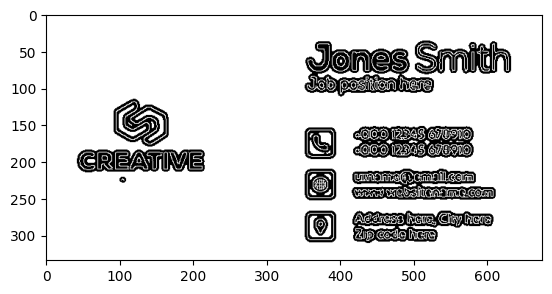

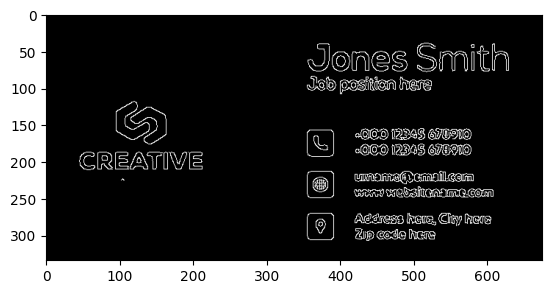

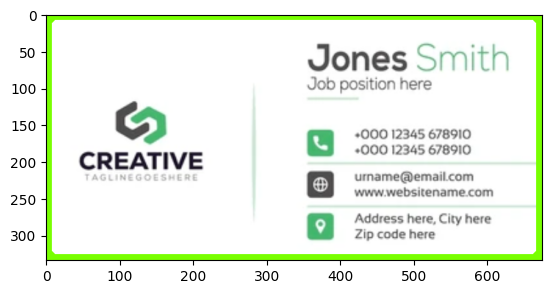

In [64]:
unsharp_mask = -1/256 * np.array([[1, 4, 6, 4, 1], [4, 16, 24, 16, 4], [6, 24, -476, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]])

img = cv.imread(test_images[1])
height, width, _ = img.shape

scale = 1

# img_scaled = cv.resize(img,(int(width*scale), int(height*scale)), cv.INTER_LANCZOS4 )

#increase brightness
# intensity_matrix = np.ones(img_scaled.shape, dtype= np.uint8) * 80
# brightened_image = cv.add(img_scaled, intensity_matrix)


#convert to gray
gray = convert_to_gray(img)

#blur for better edges
blur = cv.GaussianBlur(gray, (5,5), 0)

#edge for better ctor extraction
edged = cv.Canny(blur, 30, 200)

#find contours
conts = cv.findContours(adaptive_gausian(edged), cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)

conts = imutils.grab_contours(conts)
conts = sorted(conts, key = cv.contourArea, reverse= True)[:6]

#locate biggest contour
for c in conts:
    perimeter = cv.arcLength(c, True) #true -> means only include the closed contours
    approximation = cv.approxPolyDP(c, 0.02 * perimeter, True)  #c, epsilon, true -> means only include the closed ctors
    #note: make a fall back if it didn't work
    print(len(approximation))
    if len(approximation) == 4: #means that we found 4 sided conturn,
        print('pass')
        larger = approximation
        print(larger)
        break

cv.drawContours(img, larger, -1, (120, 255, 0), 28) #draw all the conturn of the biggest one
cv.drawContours(img, [larger], -1, (120, 255, 0), 14) #draw all the conturn of the biggest one

show_images_plt([adaptive_gausian(edged),edged, img])


In [65]:
#sort the points in:  top left, top right, bottom right, bottom left

def sort_points(points):
    points = points.reshape((4,2))
    new_points = np.zeros((4, 1, 2), dtype= np.int32)
    
    add = points.sum(1)
    dif = np.diff(points, axis= 1)

    new_points[0] = points[np.argmin(add)]
    new_points[2] = points[np.argmax(add)]

    new_points[1] = points[np.argmin(dif)]
    new_points[3] = points[np.argmax(dif)]

    return new_points

points_larger = sort_points(larger)


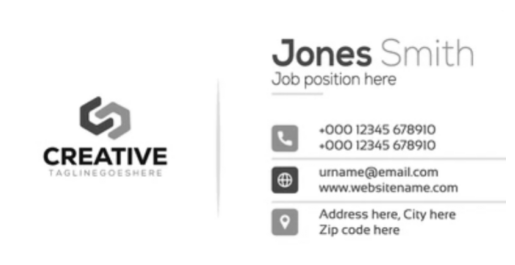

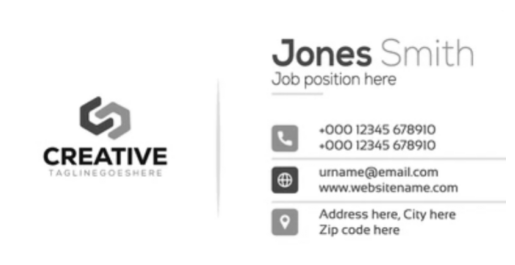

In [66]:
# transform the page

pts1 = np.float32(points_larger)
pts2 = np.float32(([[0,0], [width, 0], [width, height], [0, height]]))

matrix = cv.getPerspectiveTransform(pts1, pts2)

transform = cv.warpPerspective(gray, matrix, (width, height))

show_images_plt(transform)
transform = transform.reshape(transform.shape[0], transform.shape[1], 1)

show_images_plt(transform)


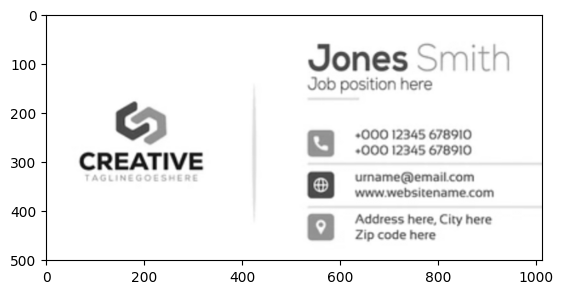

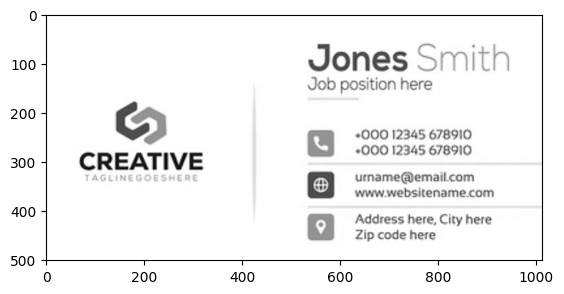

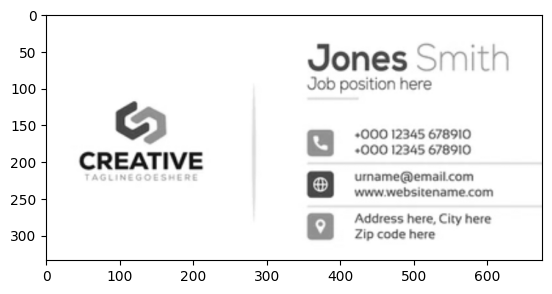

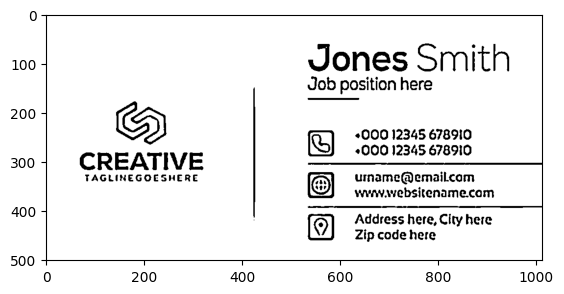

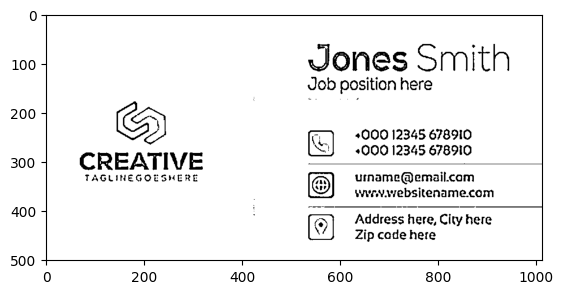

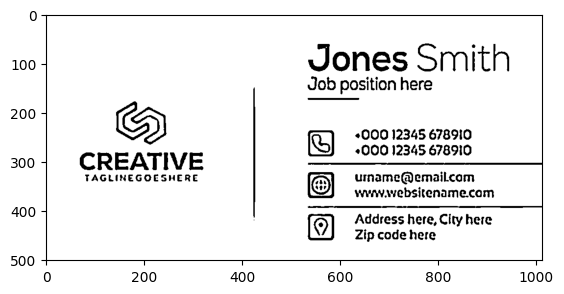

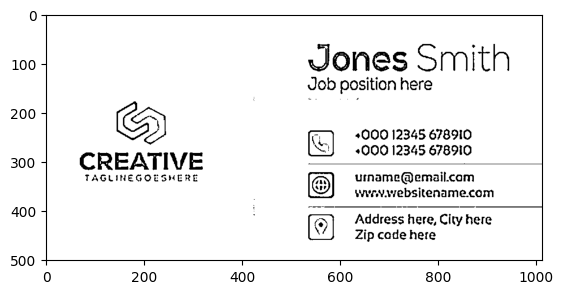

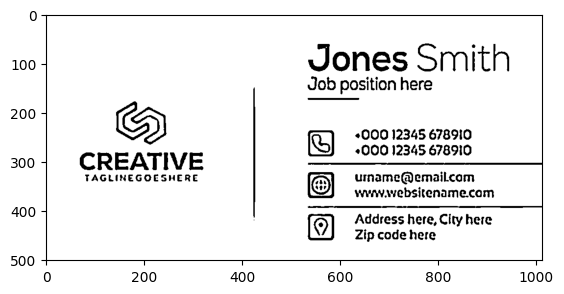

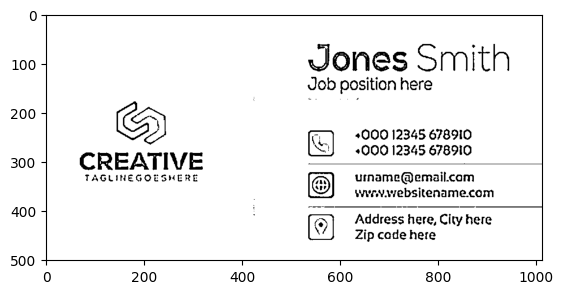

In [67]:
unsharp_mask = -1/256 * np.array([[1, 4, 6, 4, 1], [4, 16, 24, 16, 4], [6, 24, -476, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]])
kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])

height, width, _ = transform.shape

scale = 1.5
img_scaled = cv.resize(transform,(int(width*scale), int(height*scale)), cv.INTER_LANCZOS4 )



# img_scaled = transform


sharp = cv.filter2D(img_scaled, -1, unsharp_mask)
sharp_basic = cv.filter2D(img_scaled, -1, kernel)

# inv = cv.bitwise_not(sharp) #invert image color

# gray = convert_to_gray(sharp)

gau_img = gausian_threshold(sharp)
adap_image = adaptive_gausian(sharp)

dl_gau_img = cv.dilate(gau_img, np.ones((1,1), np.uint8))
dl_adap_img = cv.dilate(adap_image, np.ones((1,1), np.uint8))


er_gau_img = cv.erode(dl_gau_img, np.ones((1,1), np.uint8))
er_adap_img = cv.erode(dl_adap_img, np.ones((1,1), np.uint8))





show_images_plt([sharp, sharp_basic, gray, gau_img, adap_image,  dl_gau_img, dl_adap_img, er_gau_img, er_adap_img])


## OCR

### tesseract

In [68]:
#download eng from  https://github.com/tesseract-ocr/tessdata/blob/main/eng.traineddata?raw=true

In [69]:
#configurations
# tes.pytesseract.tesseract_cmd = r'C:\\Program Files\\Tesseract-OCR\\tesseract.exe'
# config_tesseract = '--tessdata-dir tessdata'

In [70]:
# text = tes.image_to_string(gray, lang= 'ara')
# print(text)

### EASY OCR

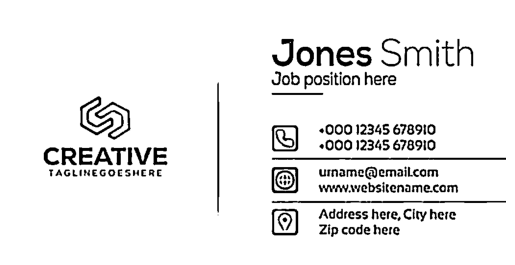

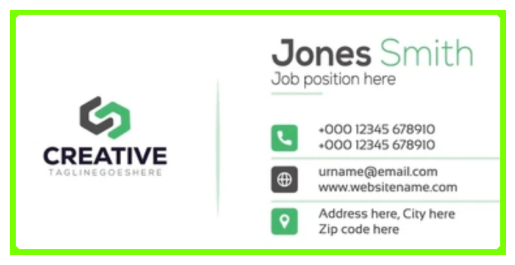

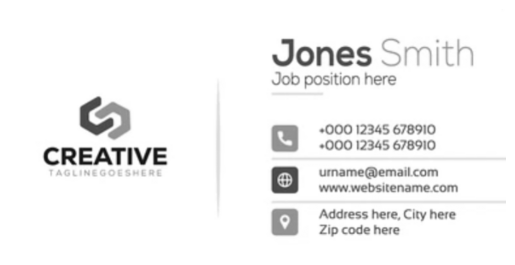

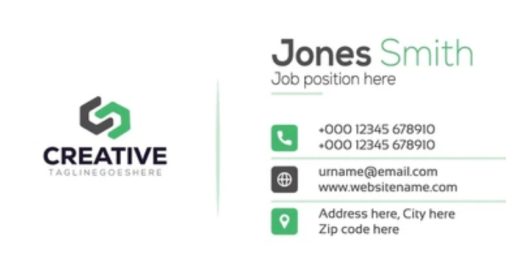

In [72]:
languages_list = ['en', 'ar']
GPU = True
original = cv.imread(test_images[1])
show_images_plt(er_gau_img)
show_images_plt(img)
show_images_plt(sharp)
show_images_plt(original)

Text recognition

In [73]:
import torch
GPU = False
if torch.cuda.is_available():
    print('cuda available')
    GPU = True

cuda available


In [86]:
languages_list = ['en']
reader = Reader(languages_list, GPU)
results = reader.readtext(er_gau_img)

In [87]:
print(type(results))

<class 'list'>


In [88]:
results[0][1]

'Jones Smith'

In [85]:
for result in results:
    print(result[1])

Jones Smith
Job position here
4000 12345 678910
#O00 12345 678910
CREATIVE
Taglinegoeseere
urname@emailcom
wvcuwebsitenamecom
Address here, Clty here
Zip code here


In [89]:
for result in results:
    print(result[1])

Jones Smith
Job position here
OO0 12345 6789i0
'O00 12345 678910
CREATIVE
Taglinegoesmere
urname@emailcom
mwcbsirenamecam
Address here; Clty herc
Zip code here


# functions for image handling and pre-processing

In [15]:
test_images = os.listdir('../card tests')
test_images = [f'../card tests/{file}' for file in test_images]

In [16]:
def adaptive_gausian(img: cv.typing.MatLike) -> cv.typing.MatLike:
    """binarization using adaptive gausian method"""
    adaptive_gausian_img = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 9)
    return adaptive_gausian_img


In [17]:
def scale_image(img: cv.typing.MatLike, c_height: int = 768 ,c_width: int = 1024, ) -> cv.typing.MatLike:
    """resize image to 1024 x 768 for better ocr results"""

    #(h, w, c)
    height, width, _ = img.shape 

    height_scale = c_height / height
    width_scale = c_width / width

    img_scaled = cv.resize(img, (int(width*width_scale), int(height*height_scale)), cv.INTER_LANCZOS4 )

    return img_scaled

In [18]:
UNSHARP_MASK = -1/256 * np.array([[1, 4, 6, 4, 1], [4, 16, 24, 16, 4], [6, 24, -476, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]])

def sharppen_img(img: cv.typing.MatLike) -> cv.typing.MatLike:
    """returns image sharppend using unsharp mask matrix"""

    sharp = cv.filter2D(img, -1, UNSHARP_MASK)

    return sharp
    

In [19]:
def gausian_threshold(img: cv.typing.MatLike) -> cv.typing.MatLike:
    """binarization using gausian method"""
    gausian_img = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 9)
    return gausian_img

In [20]:

def sort_points(points: cv.typing.MatLike):
    """sort the points in:  top left, top right, bottom right, bottom left order"""
    points = points.reshape((4,2))
    new_points = np.zeros((4, 1, 2), dtype= np.int32)
    
    add = points.sum(1)
    dif = np.diff(points, axis= 1)

    new_points[0] = points[np.argmin(add)]
    new_points[2] = points[np.argmax(add)]

    new_points[1] = points[np.argmin(dif)]
    new_points[3] = points[np.argmax(dif)]

    return new_points


In [21]:
def larger_card(new_points: cv.typing.MatLike, original_image: cv.typing.MatLike) -> cv.typing.MatLike:
    """makes the whole picture the card itself"""
    img_shape = original_image.shape

    img_height = img_shape[0]
    img_width = img_shape[1]
    
    pts1 = np.float32(new_points)
    pts2 = np.float32(([[0,0], [img_width, 0], [img_width, img_height], [0, img_height]]))

    matrix = cv.getPerspectiveTransform(pts1, pts2)

    transform = cv.warpPerspective(original_image, matrix, (img_width, img_height))

    #just to make sure it is one channel 
    transform = transform.reshape(transform.shape[0], transform.shape[1], 1)

    return (transform)


In [22]:
def extract_card(gray_image: cv.typing.MatLike) -> cv.typing.MatLike | None:
    """Extract the card it self for better results in the ocr"""

    #blur for better edges
    blur = cv.GaussianBlur(gray_image, (5,5), 0)

    #get edges for better ctor extraction
    edged = cv.Canny(blur, 30, 200)

    #find contours
    conts = cv.findContours(adaptive_gausian(edged), cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
    conts = imutils.grab_contours(conts)

    #sort it by size 
    conts = sorted(conts, key = cv.contourArea, reverse= True)[:6]

    larger = None

    #locate biggest contour
    for c in conts:
        perimeter = cv.arcLength(c, True) #true -> means only include the closed contours
        approximation = cv.approxPolyDP(c, 0.02 * perimeter, True)  #c, epsilon, true -> means only include the closed ctors
        #note: make a fall back if it didn't work
        if len(approximation) == 4: #means that we found 4 sided conturn,
            larger = approximation
            break
    
    if larger is None:
        print('no contr found')
        return None
    
    sorted_points = sort_points(larger)

    #top right - top left (take the x axis value)
    largest_contr_width = sorted_points[1] - sorted_points[0]
    largest_contr_width = largest_contr_width[0][0]

    #bottom left - bottom right (take the y axis value)
    largest_contr_height = sorted_points[3] - sorted_points[0]
    largest_contr_height = largest_contr_height[0][1]

    contr_area = largest_contr_width * largest_contr_width

    original_image_area = gray_image.shape[0] * gray_image.shape[1]

    if contr_area < int(original_image_area/2):
        print('contr area is less than 50% of the original image size')
        return None

    larger_extracted_image = larger_card(sorted_points, gray_image)

    return larger_extracted_image


    

In [36]:
def read_image_processed(path: str, is_bi: bool = True, is_sharpen: bool = True, is_extracted: bool = True) -> cv.typing.MatLike:
    """
    Reads an image from a certian path and vonvert it to gray scale

    Input:
        path (str): the image path
        brighten (int): aadjust the image brightness and contrast
        
    
    Output:
        MatLike object
    """

    #read the image
    img = cv.imread(path)

    #scale image to 1024 x 768
    scaled_img = scale_image(img)

    #convert to gray scale
    gray_image = cv.cvtColor(scaled_img, cv.COLOR_BGR2GRAY)
    
    #sharppen the image after scaling
    if is_sharpen:
        gray_image = sharppen_img(gray_image)
    
    #make the image only the card itself rather than the background 
    extracted_image = None
    if is_extracted:
        extracted_image = extract_card(gray_image)

    if extracted_image is None:
        extracted_image = gray_image
    
    

    #convert to binarized form 0 and 1 (must be gray) and dilate -> erode
    dilated_image = None
    if is_bi:
        binarized_image = gausian_threshold(extracted_image)

        # erode -> dilate = opening which is used to remove noise
        # eroded_image = cv.erode(binarized_image, np.ones((3,3), np.uint8))
        # dilated_image = cv.dilate(eroded_image, np.ones((3,3), np.uint8))
        dilated_image = binarized_image
    
    if dilated_image is None:
        dilated_image = gray_image
    

    return dilated_image


In [37]:
def show_images_plt(images: cv.typing.MatLike | List[cv.typing.MatLike]) -> None:
    """plot image or list of images using plt of matplotlib"""

    if isinstance(images, cv.typing.MatLike): 
        plt.imshow(images, cmap='grey')
        plt.axis('off')
        plt.show()

    if isinstance(images, list):
        for img in images:
            if not isinstance(img, cv.typing.MatLike): 
                continue

            plt.imshow(img, cmap='grey')
            plt.show()




no contr found


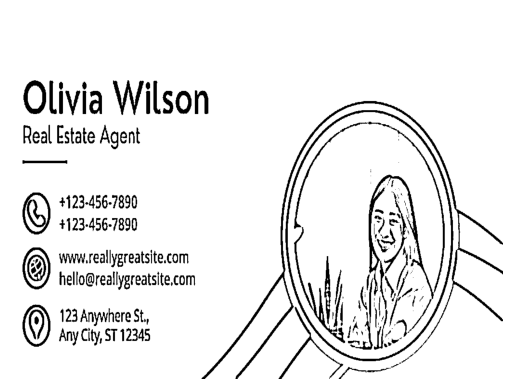

In [38]:
path = test_images[3]

img = read_image_processed(path)

show_images_plt(img)



In [39]:
GPU = False
if torch.cuda.is_available():
    print('cuda available')
    GPU = True


def read_image(img: cv.typing.MatLike, languages_list: list[str] = ['en']) -> list[str]:
    """read the image text using easy ocr, returns a list of texts which is in the img"""
    
    reader = Reader(languages_list, GPU)
    results = reader.readtext(img)

    text = []
    for result in results:
        text.append(result[1])
    
    return text


cuda available


In [40]:
text = read_image(img)
text

['Olivia Wilson',
 'Real Estate Agent',
 '+123.456.7890',
 '+123.456.7890',
 'wwwreallygreatsitecom',
 'hello@reallygreatsite,com',
 '123 Anywhere St,',
 'Any City, ST 12345']

# LLM call

In [55]:
template = PromptTemplate.from_template(
"""
You are a text corrector and text classifier; an OCR will extract details of a business card, and your job is to correct and classify the text. 

Rules:
    - Correct obvious typos based, for example, Arywhere -> Anywhere. 
    - Correct links, for example, wwwdomaincom -> www.domain.com. 
    - Do not correct words if you are uncertain of their meaning. 
    - Do not correct Names.
    - Do not correct numbers.
    - If a word contains a number in the middle, then correct it with a character instead of the number, whether it is a name or not. 
    - You must classify each part of the extracted text, even if uncertain 
    - Do not hallucinate.
    - In case you are uncertain of the class, then just include it anywhere that might be related. 
    - In case a class has info, then place the text in any other class.  
    - Output MUST have all classes even in case of it is empty.
    - Output MUST be a single JSON object, no comments, no extra text.


Classes:
    - full_name
    - phone_number
    - telephone_number
    - web_site
    - company_name
    - email
    - address
    - job_title
    - department
    - city
    - state
    - country

-----

Card Details:

{card_details}

------

Output format:
{{
    "full_name": "",
    "phone_number": "",
    "telephone_number": "",
    "web_site": "",
    "company_name": "",
    "email": "",
    "address": "",
    "job_title": "",
    "department": "",
    "city": "",
    "state": "",
}}

"""
)

In [56]:
llm = OllamaLLM(model = "command-r7b-arabic:7b")
llm_chain = (template | llm)

In [57]:
def set_up_results(results: list[str]) -> str:
    """setup card info for llm"""
    return '\n'.join(results)


In [58]:
card_details = set_up_results(text)


response = llm_chain.invoke({'card_details': card_details})
response

'{\r\n  "full_name": "Olivia Wilson",\r\n  "phone_number": "+123.456.7890",\r\n  "telephone_number": "+123.456.7890",\r\n  "web_site": "www.reallygreatsite.com",\r\n  "company_name": "",\r\n  "email": "hello@reallygreatsite.com",\r\n  "address": "123 Anywhere St, Any City, ST 12345",\r\n  "job_title": "Real Estate Agent",\r\n  "department": "",\r\n  "city": "Any City",\r\n  "state": "ST",\r\n  "country": ""\r\n}'

In [54]:
text = read_image(img)
text

['Olivia Wilson',
 'Real Estate Agent',
 '+123.456.7890',
 '+123.456.7890',
 'wwwreallygreatsitecom',
 'hello@reallygreatsite,com',
 '123 Anywhere St,',
 'Any City, ST 12345']